## Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual, monto solicitado y existencia de historial moroso. |
| **Acciones (A)** | Aprobar, aprobar con condiciones o rechazar la solicitud. |
| **Entorno (E)** | Sistema de evaluación de créditos bancarios, clientes y solicitudes de crédito. |
| **Objetivo** | Evaluar la solicitud considerando la relación monto/ingreso y el historial moroso. |
| **Medida de desempeño (P)** | Precisión de las decisiones, reducción del riesgo y tiempo de procesamiento. |

### Justificación de las reglas

Las reglas buscan relacionar el monto solicitado con el ingreso mensual del solicitante.
Una relación baja representa una menor carga relativa respecto al ingreso dentro de este modelo.
El historial moroso aumenta el nivel de riesgo, por lo que una solicitud con antecedentes negativos
no se aprueba directamente. Los casos intermedios pueden aprobarse con condiciones para reducir
el riesgo de la entidad bancaria.

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.30:
            return (
                "aprobar con condiciones",
                f"historial moroso y relacion monto/ingreso de {relacion:.2f}"
            )
        else:
            return (
                "rechazar",
                f"relacion monto/ingreso de {relacion:.2f} mayor a 0.30 "
                "con historial moroso"
            )

    else:
        if relacion <= 0.30:
            return (
                "aprobar",
                f"relacion monto/ingreso de {relacion:.2f} "
                "y sin historial moroso"
            )

        elif relacion <= 0.50:
            return (
                "aprobar con condiciones",
                f"relacion monto/ingreso de {relacion:.2f} "
                "entre 0.30 y 0.50"
            )

        else:
            return (
                "rechazar",
                f"relacion monto/ingreso de {relacion:.2f} mayor a 0.50"
            )

### Simulación y pruebas

In [ ]:
casos_credito = [
    (3000, 600, False),
    (3000, 900, False),
    (3000, 1200, False),
    (3000, 1500, False),
    (3000, 1800, False),
    (3000, 600, True)
]

for i, caso in enumerate(casos_credito, start=1):

    ingreso, monto, moroso = caso

    accion, motivo = agente_credito(
        ingreso,
        monto,
        moroso
    )

    print(f"Caso {i}")
    print(f"Ingreso: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Historial moroso: {moroso}")
    print(f"Relación: {monto / ingreso:.2f}")
    print(f"Acción: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 60)

### Visualización

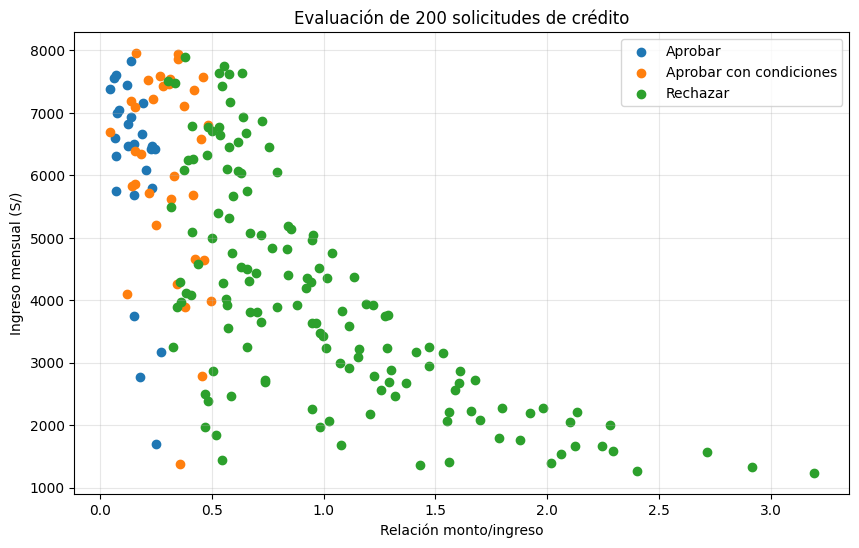

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

ingresos = np.random.randint(1200, 8001, 200)
montos = np.random.randint(300, 5001, 200)
historial_moroso = np.random.choice([True, False], 200)

relaciones = []
acciones = []

for ingreso, monto, moroso in zip(
    ingresos,
    montos,
    historial_moroso
):
    relacion = monto / ingreso

    accion, motivo = agente_credito(
        ingreso,
        monto,
        moroso
    )

    relaciones.append(relacion)
    acciones.append(accion)

relaciones = np.array(relaciones)
acciones = np.array(acciones)

plt.figure(figsize=(10, 6))

plt.scatter(
    relaciones[acciones == "aprobar"],
    ingresos[acciones == "aprobar"],
    label="Aprobar"
)

plt.scatter(
    relaciones[acciones == "aprobar con condiciones"],
    ingresos[acciones == "aprobar con condiciones"],
    label="Aprobar con condiciones"
)

plt.scatter(
    relaciones[acciones == "rechazar"],
    ingresos[acciones == "rechazar"],
    label="Rechazar"
)

plt.xlabel("Relación monto/ingreso")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Evaluación de 200 solicitudes de crédito")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()